In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import math

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'dataset',
 'data_preprocessing.ipynb',
 'Fare_Prediction.ipynb',
 'uber_fare_prediction.ipynb']

In [3]:
path="./dataset/uber.csv"
df = pd.read_csv(path)

In [4]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [15]:
def getDist(lat1, lon1, lat2, lon2):
    R=6371
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2-lat1
    dlon = lon2-lon1

    a = (math.sin(dlat/2)**2)+(math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2)
    c = 2*math.asin(math.sqrt(a))
    return R*c

In [16]:
df["dist"] = df.apply(lambda row:getDist(row["pickup_latitude"], row["pickup_longitude"], row["dropoff_latitude"], row["dropoff_longitude"]),axis=1)

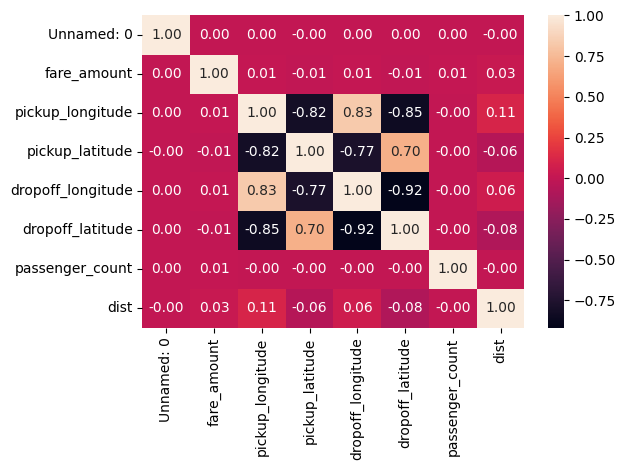

In [17]:
corr_map = df.corr('pearson', numeric_only=True)
sns.heatmap(corr_map, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

<Axes: ylabel='fare_amount'>

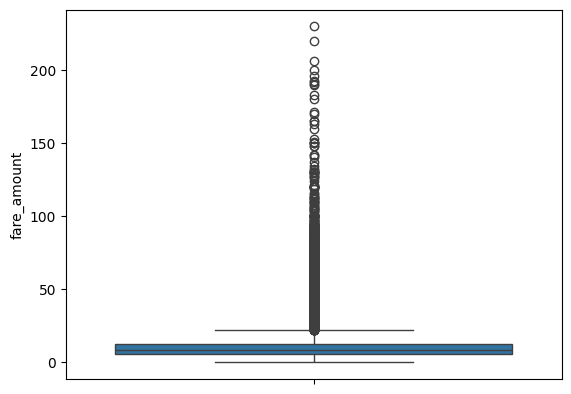

In [18]:
sns.boxplot(df["fare_amount"])

In [19]:
q1 = df["fare_amount"].quantile(0.25)
q2 = df["fare_amount"].quantile(0.75)
# df = df[(df["fare_amount"] > q1) & (df["fare_amount"] < q2)]
df = df[(df["fare_amount"] > 0) & (df["fare_amount"] < 250)]

In [20]:
X = df[["dist"]]
Y = df["fare_amount"]

In [21]:
X.shape, Y.shape

((199973, 1), (199973,))

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=12, train_size=0.7, shuffle=True)

In [23]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
model = lr_model.fit(x_train, y_train)

In [24]:
y_pred = model.predict(x_test)

In [25]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
print(f"""
RMSE={root_mean_squared_error(y_test, y_pred)}
MSE={root_mean_squared_error(y_test, y_pred)**2}
MAE={mean_absolute_error(y_test, y_pred)}
R2 Score={r2_score(y_test, y_pred)}
""")


RMSE=9.756767065791843
MSE=95.19450357612037
MAE=6.025508432375512
R2 Score=0.0005629895187577727



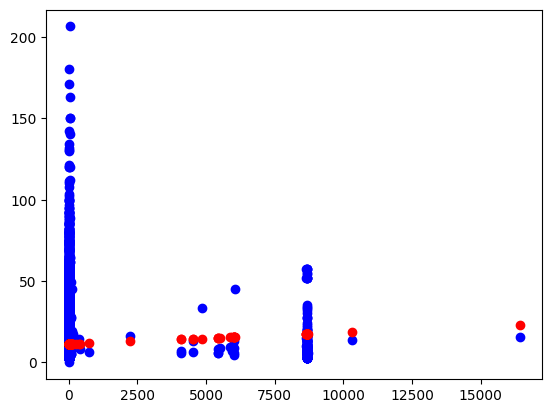

In [26]:
plt.scatter(x_test, y_test, color="blue")
plt.scatter(x_test, y_pred, color="red")
plt.show()

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(max_depth=10)
model1 = rf_model.fit(x_train, y_train)

In [33]:
y_pred = model1.predict(x_test)

In [34]:
print(f"""
RMSE={root_mean_squared_error(y_test, y_pred)}
MSE={root_mean_squared_error(y_test, y_pred)**2}
MAE={mean_absolute_error(y_test, y_pred)}
R2 Score={r2_score(y_test, y_pred)}
""")


RMSE=4.884282006743921
MSE=23.856210721402423
MAE=2.4641060546699207
R2 Score=0.7495361703762278

